# 02 · Training Experiment Comparisons: Augmentation Fix, Feature Caching, Threshold Selection

Records and analysis of three controlled experiments:

| # | Experiment | Variable | Question |
|---|------|------|------|
| A | baseline vs mask=mean | SpecAugment fill value | How much does filling with 0 (injecting a bright stripe) hurt accuracy? |
| B | real-time features vs precomputed cache | data pipeline + waveform augmentation | Is trading augmentation for speed worth it? |
| C | threshold sweep | decision threshold | Is 0.5 the optimal operating point? |

**Methodology note**: all single-seed experiments; the val set has only ~400 positives, so precision has high point-wise variance —
compare overall curve trends rather than single epochs. Early-stopping patience needs to be ≥10 (at patience=5, a lucky
epoch-3 spike once locked in a result prematurely; that run was discarded).


In [11]:
import json
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

if not Path('models').exists():
    import os; os.chdir('..')
assert Path('models').exists()

def load_hist(name):
    p = Path('models') / name
    return json.loads(p.read_text()) if p.exists() else None

runs = {
    'realtime, mask=0 (baseline)': load_hist('training_history_baseline.json'),
    'realtime, mask=mean':          load_hist('training_history.json'),
    'cached + SpecAugment only':    load_hist('training_history_cached.json'),
}
for k, v in runs.items():
    print(f"{k:36s}: {'--' if v is None else str(len(v)) + ' epochs'}")

realtime, mask=0 (baseline)         : 17 epochs
realtime, mask=mean                 : 25 epochs
cached + SpecAugment only           : 33 epochs


## Experiments A + B: Training Curve Comparison

All three curves plotted together. Points to notice:
- The **peaks** of all three F1 curves are nearly identical (0.930–0.933) → neither the mask-fill bug nor dropping waveform augmentation hurt accuracy
- The cached run's (green) **val loss is noticeably lower** and still trending down at the end → cleaner training signal, and not yet converged
- Precision jitters heavily across all configs → this is a systemic effect of pos_weight=25 + fixed threshold + sparse val positives, unrelated to configuration


run                                      best F1  @epoch  ~s/epoch
realtime, mask=0 (baseline)                0.933      12        71
realtime, mask=mean                        0.930      15        71
cached + SpecAugment only                  0.949      23        30


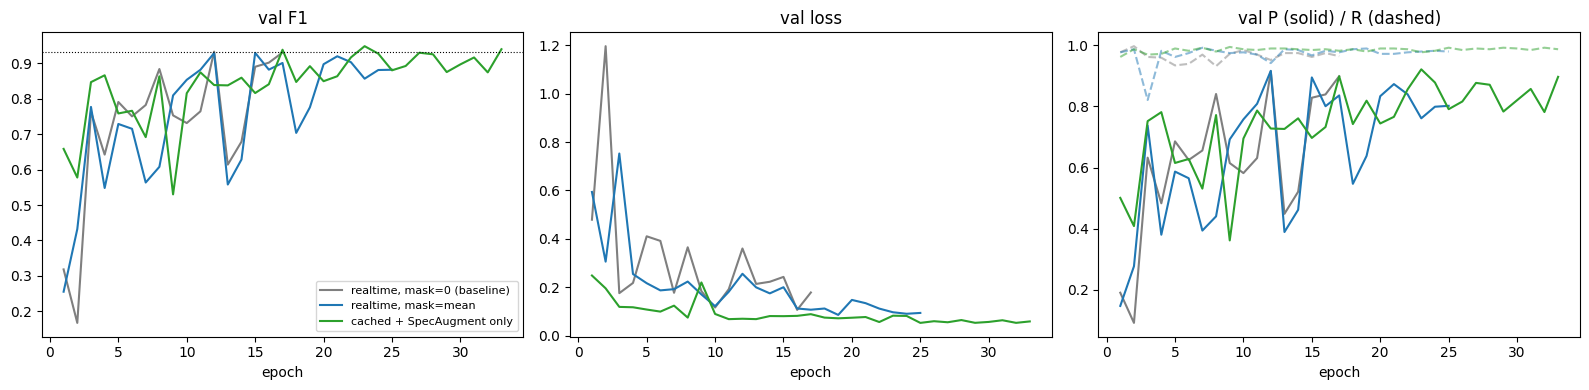

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {'realtime, mask=0 (baseline)': 'tab:gray',
          'realtime, mask=mean': 'tab:blue',
          'cached + SpecAugment only': 'tab:green'}

for name, hist in runs.items():
    if hist is None:
        continue
    ep = [h['epoch'] for h in hist]
    c = colors[name]
    axes[0].plot(ep, [h['f1'] for h in hist], label=name, color=c)
    axes[1].plot(ep, [h['loss'] for h in hist], label=name, color=c)
    axes[2].plot(ep, [h['precision'] for h in hist], color=c, label=f'{name} (P)')
    axes[2].plot(ep, [h['recall'] for h in hist], color=c, ls='--', alpha=0.5)

axes[0].set_title('val F1'); axes[0].set_xlabel('epoch'); axes[0].legend(fontsize=8)
axes[0].axhline(0.933, ls=':', c='k', lw=0.8)
axes[1].set_title('val loss'); axes[1].set_xlabel('epoch')
axes[2].set_title('val P (solid) / R (dashed)'); axes[2].set_xlabel('epoch')
plt.tight_layout()

print(f"{'run':38s}  {'best F1':>8s}  {'@epoch':>6s}  {'~s/epoch':>8s}")
sec = {'realtime, mask=0 (baseline)': 71, 'realtime, mask=mean': 71,
       'cached + SpecAugment only': 30}
for name, hist in runs.items():
    if hist is None:
        continue
    best = max(hist, key=lambda h: h['f1'])
    print(f"{name:38s}  {best['f1']:8.3f}  {best['epoch']:6d}  {sec[name]:8d}")

### Final Conclusions (A + B)

| Config | s/epoch | best F1 | speedup (vs CPU 338s) |
|---|---|---|---|
| CPU + real-time features | 338 | — | 1× |
| GPU + real-time features, mask=0 | ~71 | 0.933 | 4.8× |
| GPU + real-time features, mask=mean | ~71 | 0.930 | 4.8× |
| GPU + cached, SpecAugment only | ~30 | 0.933 | **11.3×** |

1. **The mask-fill bug caused no measurable accuracy loss** — the model learned the bright stripe as just another kind of noise.
   Still worth fixing: correctness should come from design, not luck; and this bug was found by eye on a spectrogram plot while pytest was fully green
   (the test fixture used an all-ones array, where mean=1 makes the fill-value distinction degenerate to nothing).
2. **Caching traded zero accuracy loss for a 2.4× speedup** — at this scale (84k samples, 20k params),
   SpecAugment alone provided enough regularization. Caveat: needs retesting after switching to a small, self-recorded wake-word dataset.
3. The cached run's val F1 was still climbing at epoch 30 (lowest val loss of all runs) — the true ceiling may be >0.94.


## Experiment C: Threshold Sweep

Using 0.5 during training was just for convenience. When deploying a wake-word system, the operating point should be derived from product constraints —
e.g. "false wake-ups ≤ N per day" sets a precision floor, and recall should be maximized within that constraint.
Below: collect all scores on val in a single forward pass, then sweep every threshold.


In [13]:
from my_kws.cached_datasets import CachedKeywordSpottingDataset
from my_kws.model import DSCNN
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt = torch.load('models/dscnn_best_cached.pt', map_location=device, weights_only=False)
model = DSCNN().to(device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f"loaded checkpoint from epoch {ckpt['epoch']}, val F1 {ckpt['val_f1']:.3f}")

val_ds = CachedKeywordSpottingDataset(split='val', training=False)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

scores, labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        scores.append(torch.sigmoid(model(x.to(device))).cpu().squeeze(1))
        labels.append(y)
scores = torch.cat(scores).numpy()
labels = torch.cat(labels).numpy().astype(bool)
print(f"{len(scores)} val samples, {labels.sum()} positives")

loaded checkpoint from epoch 23, val F1 0.949
9981 val samples, 397 positives


threshold 0.50            : P=0.922 R=0.977 F1=0.949
best threshold 0.85      : P=0.982 R=0.960 F1=0.971
P>=0.95 约束下最优 (0.74): P=0.950 R=0.962 F1=0.956


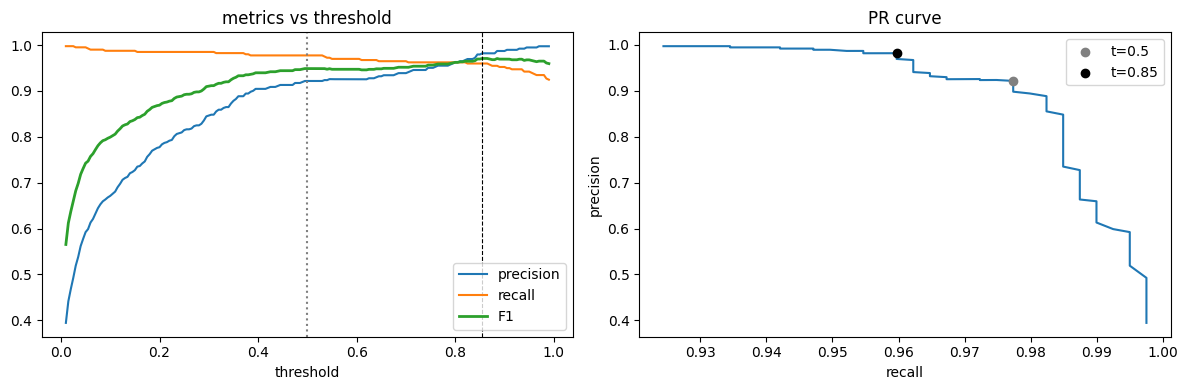

In [14]:
thresholds = np.linspace(0.01, 0.99, 197)
P, R, F1 = [], [], []
for t in thresholds:
    pred = scores >= t
    tp = (pred & labels).sum(); fp = (pred & ~labels).sum(); fn = (~pred & labels).sum()
    p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
    P.append(p); R.append(r); F1.append(2*p*r / max(p + r, 1e-9))
P, R, F1 = map(np.array, (P, R, F1))

best_i = F1.argmax()
i05 = np.abs(thresholds - 0.5).argmin()
print(f"threshold 0.50            : P={P[i05]:.3f} R={R[i05]:.3f} F1={F1[i05]:.3f}")
print(f"best threshold {thresholds[best_i]:.2f}      : P={P[best_i]:.3f} R={R[best_i]:.3f} F1={F1[best_i]:.3f}")

# Example of a product-oriented operating point: maximize recall subject to precision >= 0.95
mask = P >= 0.95
if mask.any():
    j = np.where(mask)[0][R[mask].argmax()]
    print(f"best under P>=0.95 constraint ({thresholds[j]:.2f}): P={P[j]:.3f} R={R[j]:.3f} F1={F1[j]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(thresholds, P, label='precision')
axes[0].plot(thresholds, R, label='recall')
axes[0].plot(thresholds, F1, label='F1', lw=2)
axes[0].axvline(0.5, ls=':', c='gray'); axes[0].axvline(thresholds[best_i], ls='--', c='k', lw=0.8)
axes[0].set_xlabel('threshold'); axes[0].legend(); axes[0].set_title('metrics vs threshold')
axes[1].plot(R, P)
axes[1].scatter([R[i05]], [P[i05]], c='gray', zorder=3, label='t=0.5')
axes[1].scatter([R[best_i]], [P[best_i]], c='k', zorder=3, label=f't={thresholds[best_i]:.2f}')
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision')
axes[1].set_title('PR curve'); axes[1].legend()
plt.tight_layout()

## Final Test Set Evaluation (done exactly once for all of Chunk 2)

Rule: val is used for all tuning and model selection; test is evaluated exactly once, on the **final chosen model + threshold**.
The number is recorded as-is regardless of how it looks — no going back to change the configuration, or test would just become a second val.


In [15]:
FINAL_THRESHOLD = round(float(thresholds[best_i]), 3)   # chosen from the val sweep in the previous section

test_ds = CachedKeywordSpottingDataset(split='test', training=False)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)

s, l = [], []
with torch.no_grad():
    for x, y in test_loader:
        s.append(torch.sigmoid(model(x.to(device))).cpu().squeeze(1))
        l.append(y)
s = torch.cat(s).numpy(); l = torch.cat(l).numpy().astype(bool)

pred = s >= FINAL_THRESHOLD
tp = (pred & l).sum(); fp = (pred & ~l).sum(); fn = (~pred & l).sum(); tn = (~pred & ~l).sum()
p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
print(f"TEST SET ({len(s)} samples, {l.sum()} positives) @ threshold {FINAL_THRESHOLD:.3f}")
print(f"  precision {p:.3f} | recall {r:.3f} | F1 {2*p*r/max(p+r,1e-9):.3f}")
print(f"  confusion: TP={tp} FP={fp} FN={fn} TN={tn}")

TEST SET (11005 samples, 419 positives) @ threshold 0.855
  precision 0.998 | recall 0.964 | F1 0.981
  confusion: TP=404 FP=1 FN=15 TN=10585


---
**Chunk 2 completion criterion**: done once the test number above is locked in.

**Chunk 3 preview (edge deployment direction)**:
Model export (TorchScript / ONNX) → post-training quantization (float32 → int8, 20k-param model shrinks
from ~80KB → ~20KB) → accuracy comparison before/after quantization → streaming inference prototype (sliding window + `record_wakewords.py`
real recordings). This line directly maps to the role requirement "automated toolchain validation."
